# 前半段：先对MLP进行一番补充，提升理解

本节目标：把 Day5 跑通的单隐层 MLP 重新训一遍，确认三件事——
1. 同样的种子与超参下，200k 步小批量训练的 loss 能否复现（起点 ~27.9，终点 train/val ~2.1）；
2. 损失曲线与采样名字是否符合预期（为后面的"症状分析"留一个健康基线）；
3. 热身之后，再带着"初始 loss 太大、tanh 饱和"这两个疑问进入第三阶段。

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
from pathlib import Path
words = Path('names.txt')
if not words.exists():
    words = Path.cwd() / 'names.txt'
words = words.read_text(encoding='utf-8').splitlines()
words[:8]


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)


32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])    # 80%
Xdev, Ydev = build_dataset(words[n1:n2])  # 10%
Xte,  Yte  = build_dataset(words[n2:])   # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_emb = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact) # hidden layer pre-activation
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.8137
  20000/ 200000: 2.5107
  30000/ 200000: 2.8047
  40000/ 200000: 2.0610
  50000/ 200000: 2.6743
  60000/ 200000: 2.3679
  70000/ 200000: 2.0702
  80000/ 200000: 2.2550
  90000/ 200000: 2.2825
 100000/ 200000: 2.0023
 110000/ 200000: 2.3095
 120000/ 200000: 1.8914
 130000/ 200000: 2.4168
 140000/ 200000: 2.2163
 150000/ 200000: 2.1790
 160000/ 200000: 2.0718
 170000/ 200000: 1.7637
 180000/ 200000: 2.0273
 190000/ 200000: 1.8378


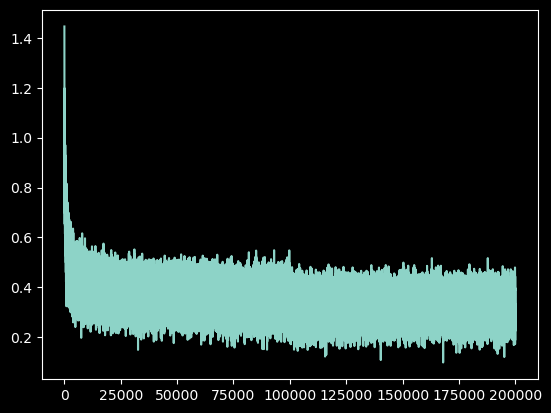

In [8]:
plt.plot(lossi)


In [9]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_emb)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_emb)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1256096363067627
val 2.1673810482025146


In [10]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join([itos[i] for i in out])) # decode and print the generated word

carlah.
amille.
khi.
mri.
rey.
casplayson.
mahnen.
den.
arc.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quint.
salin.
alianni.
wazthoniearynix.
kaelissuli.


### 第一阶段结果（loss 曲线 / train/val / 采样）

- 损失曲线（cell 9 输出的那张图）：纵轴是 $\log_{10}$ 损失。初始 loss 从约 1.45 开始，前 1 万步内迅速降到 0.3-0.5 的平台（对应自然损失约 2-3），之后在平台附近波动到最后。曲线很“抖”是因为 batch_size=32，每个 batch 的损失波动大——这是小 batch 训练的常态，不是 bug。
- 评估（train 2.13 / val 2.17）：两者接近，说明这个简单的单隐层模型没有明显过拟合。
- 采样：模型分出的风格已接近英文人名（mora、yam、jose 等），但也有 adelynnelin 这类重复拼接的错误——属于还没学透的正常表现。

# 下面进入第三阶段
## 先分析已有的问题
1. 初始的loss太大了，不符合数学预期——b2在初始化时变为0，W2初始化变小（* 0.01) —— 可以减少用来“压缩权重”的轮次
> `W2` 设为 0 会让所有类别的初始 logit 完全相同，初始预测接近均匀分布。这里使用很小的随机值，是为了同时保持低置信度并打破参数对称性。


2. `h` 的分布：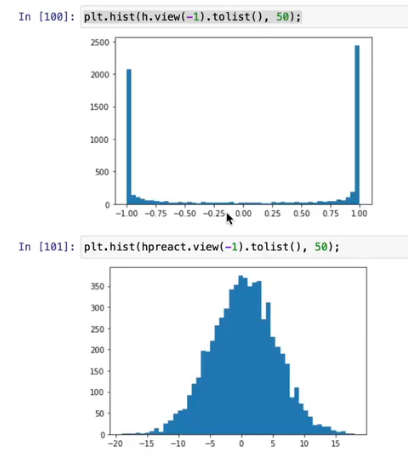

> 图 1：初始 `hpreact`/隐藏层激活的直方图（下图是 `hpreact`，横跨约 ±20；上图是 `h`，两端堆满柱子）。两端的大量柱子表示数值靠近边界，提示 `tanh` 可能进入饱和区。 当 `hpreact` 的绝对值很大时，`tanh` 输出会靠近 `-1` 或 `1`，由 $1-\tanh^2(x)$ 可知局部梯度会变小。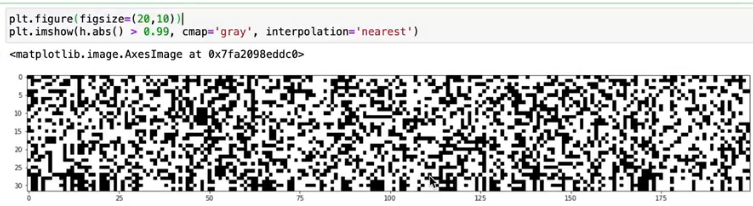

> 图 2：按阈值标出饱和激活的示意图。黑白区域用于观察哪些位置接近 `tanh` 的输出边界，不能单独作为“梯度一定正常”的证明。图中大面积饱和区表示许多激活靠近边界；不能仅凭“没有整条白色”判断梯度充分，仍应结合后面的激活梯度直方图与均值/标准差。
> `sigmoid` 同样可能在饱和区产生小梯度；`ReLU` 在负半轴则可能出现零梯度。不同激活函数的失效原因不同。

如何修复呢？—— b1 * 0.01   W1 * 0.1
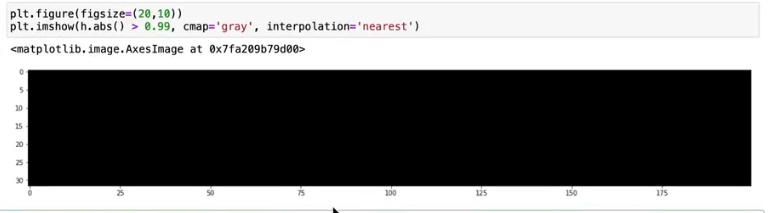

> 图 3：缩放初始化相关的代码结果。它对应减小 `W1`/`b1` 初始尺度，让进入 `tanh` 的信号更集中在可传递梯度的区域。

缩放后的结果： 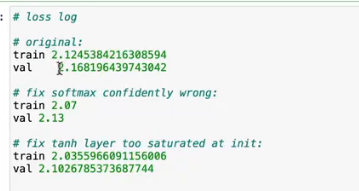

> 图 4：缩放初始化后的 train/val loss 输出，用来和前面的饱和现象对照，观察优化起点是否改善。

### 图像解读

- 第一张直方图中的 `hpreact` 大量集中在两端，说明进入 `tanh` 前的信号幅度偏大。
- 第二张直方图展示 `tanh` 输出接近 `-1/1` 的程度；越靠近边界，导数越小。
- 第三张图对应缩放初始化后的信号，第四张图对应其 train/val loss 结果；两者共同用于观察初始化是否改善优化起点。


tensor(0.0044) tensor(0.9902)
tensor(-0.0019) tensor(0.9761)


(array([2.20761273e-05, 2.20761273e-05, 8.83045091e-05, 1.32456764e-04,
        6.62283819e-05, 1.76609018e-04, 3.09065782e-04, 3.75294164e-04,
        5.07750928e-04, 1.39079602e-03, 2.36214562e-03, 4.45937771e-03,
        7.17474137e-03, 1.05744650e-02, 1.81686528e-02, 2.87872700e-02,
        4.51898326e-02, 6.60517728e-02, 1.02234545e-01, 1.42126107e-01,
        2.05020994e-01, 2.60564530e-01, 3.24143777e-01, 3.84102539e-01,
        4.23596730e-01, 4.31190918e-01, 4.15384411e-01, 3.72600876e-01,
        3.16682046e-01, 2.53213180e-01, 1.89876771e-01, 1.37445968e-01,
        9.56779357e-02, 6.53232606e-02, 4.21212509e-02, 2.57849167e-02,
        1.63142581e-02, 1.03316276e-02, 6.82152333e-03, 3.86332228e-03,
        2.14138435e-03, 1.25833926e-03, 7.28512200e-04, 3.53218037e-04,
        3.09065782e-04, 6.62283819e-05, 4.41522546e-05, 0.00000000e+00,
        2.20761273e-05, 2.20761273e-05]),
 array([-5.75998592, -5.53349692, -5.30700792, -5.08051892, -4.85402992,
        -4.62754092, 

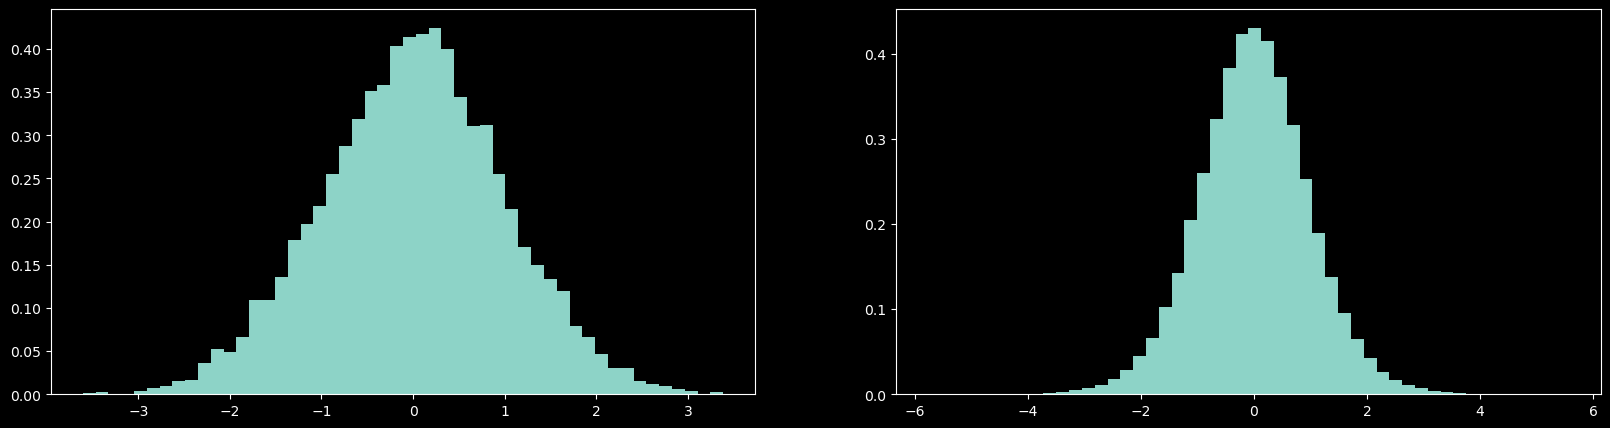

In [11]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5  #(连接数的平方根)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

### 上图（x 与 y 的分布）如何读取

两张直方图分别是 `x`（输入，std≈0.99）与 `y = x@w`（权重按 `1/sqrt(10)` 缩放后的输出，std≈1.01）。两者都近似标准正态，说明“按连接数平方根缩放权重”能让线性层输出的方差保持稳定——这就是 Kaiming 初始化的直观来源。

下面做个对照：不缩放权重时，`y` 的方差会放大成什么样子。

不缩放:    y.std() = 3.1160166263580322
按sqrt缩放: y.std() = 0.9812744855880737


Text(0.5, 1.0, 'y = x @ w (w / sqrt(fan_in))')

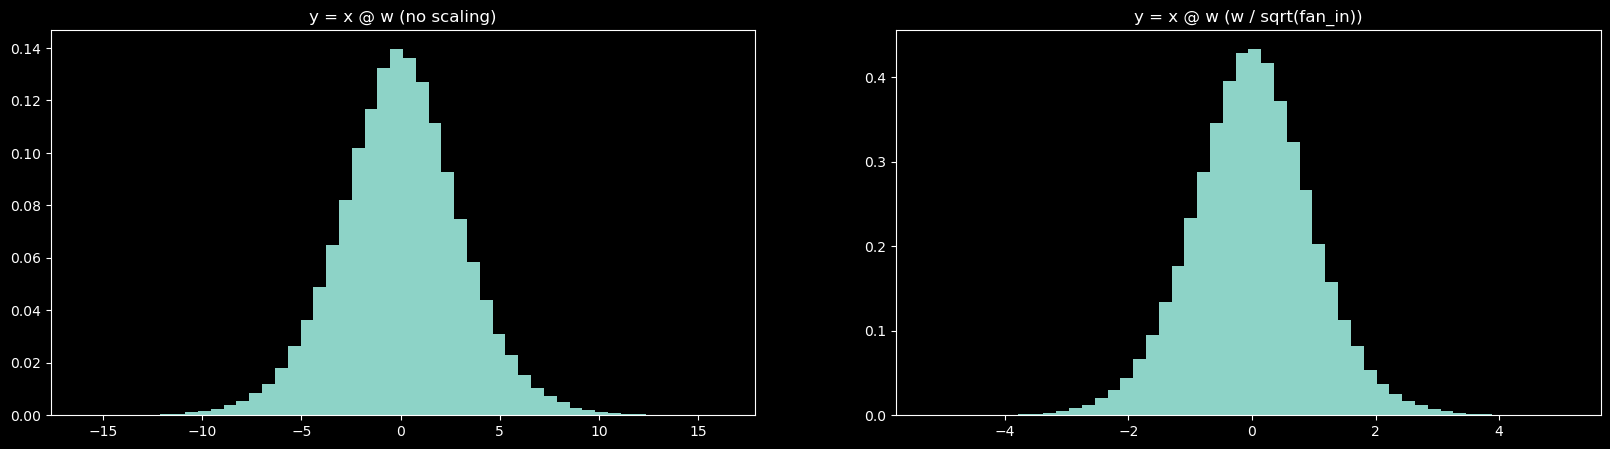

In [12]:
# 对比实验 1：线性层初始化缩放 vs 不缩放，对输出方差的影响
x_cmp = torch.randn(1000, 10)
w_plain = torch.randn(10, 200)              # 不缩放
w_scaled = torch.randn(10, 200) / 10**0.5   # 按连接数平方根缩放
y_plain = x_cmp @ w_plain
y_scaled = x_cmp @ w_scaled
print('不缩放:    y.std() =', y_plain.std().item())
print('按sqrt缩放: y.std() =', y_scaled.std().item())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(y_plain.view(-1).tolist(), 50, density=True)
plt.title('y = x @ w (no scaling)')
plt.subplot(122)
plt.hist(y_scaled.view(-1).tolist(), 50, density=True)
plt.title('y = x @ w (w / sqrt(fan_in))')

## 现代创新
1. 归一化
2. 残差连接
3. 优化器

## Kaiming 初始化
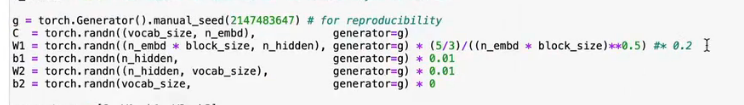

> 图 5：Kaiming 初始化的代码片段，核心是按输入连接数缩放权重，使线性层输出的方差不随层数快速放大或缩小。
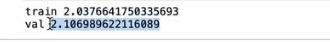

> 图 6：Kaiming 缩放初始化后 MLP 的 train/val loss 结果（train 2.04 / val 2.11），与 图 4 的“修复 tanh 饱和”同族——按连接数平方根缩放权重同样能改善优化起点。

归一化的代表作是 Ioffe & Szegedy 的《Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift》(ICML 2015, arXiv:1502.03167)，下面就按它的思路动手。

## 批归一化
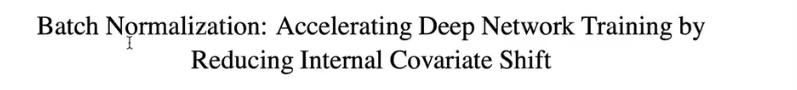

> 图 7：BatchNorm 论文《Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift》的标题截图，本节的“现代创新 1：归一化”即源于这篇论文。
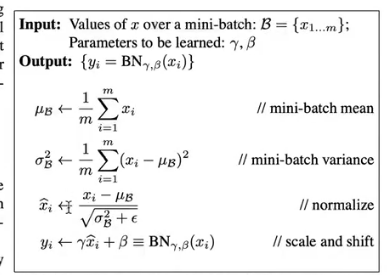

> 图 8：BatchNorm 的训练/前向公式：先算 mini-batch 均值 μ_B 与方差 σ²_B，再归一化 $\hat{x}$，最后用可学习 γ、β 做缩放平移得到 $y_i = BN_{\gamma,\beta}(x_i)$。
修改点：
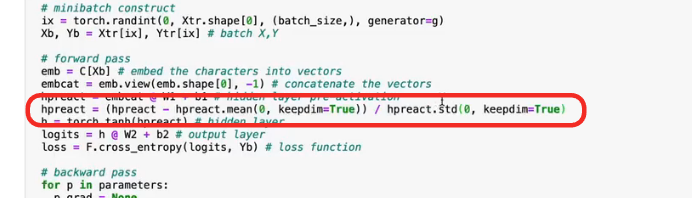

> 图 9：修改点在训练循环里的样子（红框）：`hpreact` 先减去当前 batch 的均值、再除以标准差。先不引入 γ/β，完整版见后面两图。
BatchNorm 还有两个可学习参数：缩放与平移：
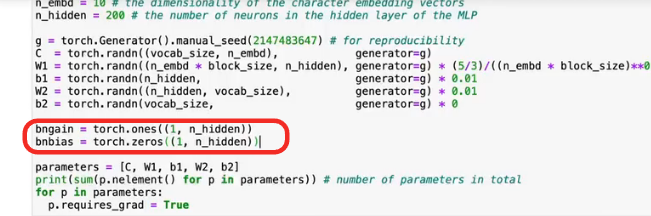

> 图 10：BatchNorm 的可学习参数初始化（红框）：`bngain`（γ）从 1 开始、`bnbias`（β）从 0 开始，初始时保持归一化后的信号尺度。
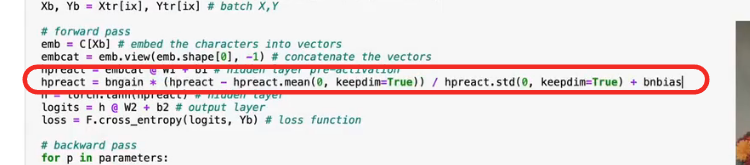

> 图 11：训练循环中的完整 BatchNorm 实现（红框）：先算当前 mini-batch 的平均/标准差，再用 `bngain` 缩放、`bnbias` 平移，之后才进入 `tanh`。

成果：
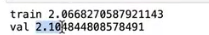

> 图 12：BatchNorm 实验的 loss 输出，用于观察加入归一化后的训练结果。

> 训练态下，BatchNorm 使用当前 mini-batch 的均值和标准差，因此同一个样本会随 batch 组成产生轻微变化。这种统计噪声可能带来正则化效果，但它不是数据增强；推理态应使用运行统计量。

### 图像解读

- 前两张图对应 Kaiming 初始化的代码（图 5）与缩放后的 loss 日志（图 6）。
- 图 7/图 8 是 BatchNorm 论文标题与训练公式；图 9-图 11 是代码里的归一化、缩放平移与训练态实现。
- 最后一张结果图（图 12）需结合 train/val loss 一起看，不能只凭单条曲线判断。


```
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    emcat = emb.view(emb.shape[0], -1)
    hpreact = emcat @ W1 + b1
    # measure the mean/std over the entire training set
    bmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)
```
\+
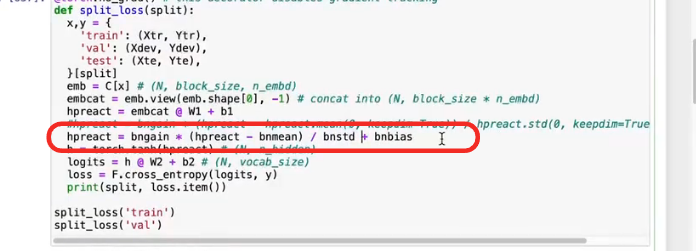

> 图 13：评估用的 `split_loss`（红框）：用上面全训练集统计出的 `bnmean`/`bnstd` 做归一化——推理/评估态用的不是当前 batch 的统计量。

以及（下面两图分别展示 batch 统计与运行统计的差异）：

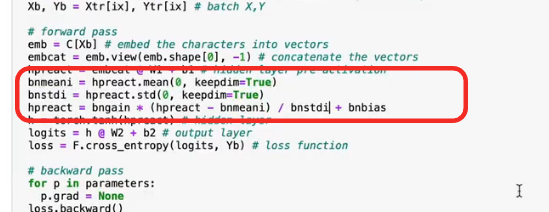

> 图 14：BN 参数的初始化：`bngain`/`bnbias` 是可学习参数；`bnmean_running`/`bnstd_running` 是不参与反向传播的缓冲统计量，推理态由它们提供均值与方差。

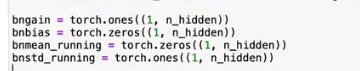

> 图 15：训练循环里的 batch 统计量（红框）：`bmeani`/`bnstdi` 是当前 mini-batch 的均值/标准差，归一化只用它们（running 统计量的更新见下方代码块）。

`running_mean` 与 `running_var` 是不参与反向传播的缓冲统计量；训练时更新它们，推理时使用它们。
```
with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean1
    bnst1_running = 0.999 * bnst1_running + 0.001 * bnst1
```

注意：由于我们使用了归一化，所以某些步骤的偏置会失去作用，例如b1，因为这个偏置无论如何会被减去抵消。

### 图像解读

- 图 13 是评估函数里用 `bnmean`/`bnstd`（运行统计量）做归一化；图 14 是 BN 参数与运行缓冲的初始化；图 15 是训练循环中按当前 batch 统计归一化。
- 训练态使用当前 batch，推理态使用不参与反向传播的 running 统计。
- 由于归一化会减去均值，`b1` 的整体偏移会被抵消，归一化后的可学习偏移主要由 `bnbias` 提供。


In [13]:

# MLP revisited
n_emb = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3)/(n_emb * block_size)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bmean_running = torch.zeros((1, n_hidden))
bstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b1, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12270


In [14]:
# 以上，需要你结合图片和笔记中提到的论文，把它下载下来并精读，然后根据你学习的内容，对我的notebook文件进行补充优化。

# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    bmeani = hpreact.mean(0, keepdim=True)
    bstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bmeani) / (bstdi + 1e-5) + bnbias # normalize, then scale and shift
    bmean_running = 0.999 * bmean_running + 0.001 * bmeani.detach()
    bstd_running = 0.999 * bstd_running + 0.001 * bstdi.detach()
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}]:{loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000]:3.3147
  10000/ 200000]:2.1562
  20000/ 200000]:2.2741
  30000/ 200000]:2.4363
  40000/ 200000]:1.9870
  50000/ 200000]:2.2975
  60000/ 200000]:2.3679
  70000/ 200000]:2.1573
  80000/ 200000]:2.4078
  90000/ 200000]:2.1910
 100000/ 200000]:1.9062
 110000/ 200000]:2.3093
 120000/ 200000]:1.9429
 130000/ 200000]:2.4545
 140000/ 200000]:2.3486
 150000/ 200000]:2.1840
 160000/ 200000]:1.9586
 170000/ 200000]:1.7782
 180000/ 200000]:2.1540
 190000/ 200000]:1.9129


## Pytorch优化

把 `Linear` / `BatchNorm` / `Tanh` 封装成类，再堆出 4 个隐层的深网。模块化之后做两件事更顺手：一是把"缩放初始化"写进类的构造里，二是给每一层的输出挂上 `retain_grad`，凑齐激活 / 梯度 / 更新比例三套诊断。

In [15]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn(fan_in, fan_out) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)  # batch mean
            xvar = x.var(0, keepdim=True, unbiased=False)  # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)  # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_emb = 10  # the dimensionality of the character embedding vectors
n_hidden = 100  # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((vocab_size, n_emb), generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]
with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

36397


In [16]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers :
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for l in layers:
        l.out.retain_grad()  # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])


      0/ 200000: 3.2792
  10000/ 200000: 2.2546
  20000/ 200000: 1.7989
  30000/ 200000: 1.8155
  40000/ 200000: 2.4103
  50000/ 200000: 2.2548
  60000/ 200000: 1.6488
  70000/ 200000: 2.2379
  80000/ 200000: 1.9687
  90000/ 200000: 1.7038
 100000/ 200000: 1.7278
 110000/ 200000: 2.0176
 120000/ 200000: 1.6799
 130000/ 200000: 1.6217
 140000/ 200000: 2.0095
 150000/ 200000: 1.8292
 160000/ 200000: 1.7620
 170000/ 200000: 2.2221
 180000/ 200000: 1.9253
 190000/ 200000: 1.8529


### 对比实验 2：加不加 `BatchNorm1d`，短训练内的差异

上面的深层 MLP 没有 BatchNorm，诊断图显示激活饱和、梯度偏小。下面用完全相同的结构与初始化，各训练 2000 步：一个在每层 `Linear` 与 `Tanh` 之间插入 `BatchNorm1d`（即下一步要做的内容），一个保持原样，直接对比 loss 曲线。

注意：这只是一次短训练快照——初始化已经修好的前提下，2000 步内 BN 的优势不一定立刻显现（噪声本身就大于差距）。BatchNorm 的真正价值更偏向于让网络不敏感于初始化细节、并支持更大的学习率，这正是下一步要验证的方向。

无 BatchNorm1d   训练 2000 步后 log10 loss: 0.3627282977104187
有 BatchNorm1d   训练 2000 步后 log10 loss: 0.3865516483783722


Text(0.5, 1.0, 'short training: BatchNorm vs no BatchNorm')

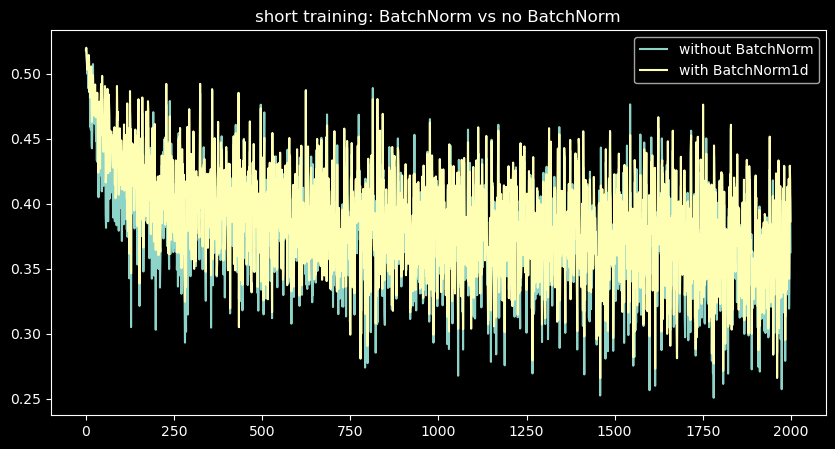

In [17]:
# 对比实验 2：同一个深层 MLP，有无 BatchNorm1d，各训练 2000 步
def build_net(with_bn):
    torch.manual_seed(2147483647)  # 两组用完全相同种子，保证初始化可比
    C_n = torch.randn((vocab_size, n_emb))
    if with_bn:
        layers_n = [
            Linear(n_emb * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
            Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
            Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
            Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
            Linear(n_hidden, vocab_size),
        ]
    else:
        layers_n = [
            Linear(n_emb * block_size, n_hidden), Tanh(),
            Linear(n_hidden, n_hidden), Tanh(),
            Linear(n_hidden, n_hidden), Tanh(),
            Linear(n_hidden, n_hidden), Tanh(),
            Linear(n_hidden, vocab_size),
        ]
    with torch.no_grad():
        # last layer: make less confident
        layers_n[-1].weight *= 0.1
        for layer in layers_n[:-1]:
            if isinstance(layer, Linear):
                layer.weight *= 5/3
    params_n = [C_n] + [p for layer in layers_n for p in layer.parameters()]
    for p in params_n:
        p.requires_grad = True
    return C_n, layers_n, params_n

def train_short(C_n, layers_n, params_n, max_steps=2000, lr=0.1):
    g_cmp = torch.Generator().manual_seed(21474836481)  # 两组使用完全相同的 mini-batch 序列
    lossi_n = []
    for i in range(max_steps):
        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g_cmp)
        Xb, Yb = Xtr[ix], Ytr[ix]
        # forward pass
        emb = C_n[Xb]
        x = emb.view(emb.shape[0], -1)
        for layer in layers_n:
            x = layer(x)
        loss = F.cross_entropy(x, Yb)
        # backward pass
        for p in params_n:
            p.grad = None
        loss.backward()
        # update
        for p in params_n:
            p.data += -lr * p.grad
        lossi_n.append(loss.log10().item())
    return lossi_n

C_plain, layers_plain, params_plain = build_net(with_bn=False)
C_bn, layers_bn, params_bn = build_net(with_bn=True)
lossi_plain = train_short(C_plain, layers_plain, params_plain)
lossi_bn = train_short(C_bn, layers_bn, params_bn)
print('无 BatchNorm1d   训练 2000 步后 log10 loss:', lossi_plain[-1])
print('有 BatchNorm1d   训练 2000 步后 log10 loss:', lossi_bn[-1])

plt.figure(figsize=(10, 5))  # width and height of the plot
plt.plot(lossi_plain, label='without BatchNorm')
plt.plot(lossi_bn, label='with BatchNorm1d')
plt.legend()
plt.title('short training: BatchNorm vs no BatchNorm')

layer 1, Tanh: mean=-0.01, std=0.87, saturated=48.06%
layer 3, Tanh: mean=0.03, std=0.89, saturated=54.59%
layer 5, Tanh: mean=-0.02, std=0.90, saturated=55.84%
layer 7, Tanh: mean=-0.01, std=0.85, saturated=40.84%


Text(0.5, 1.0, 'activation distribution')

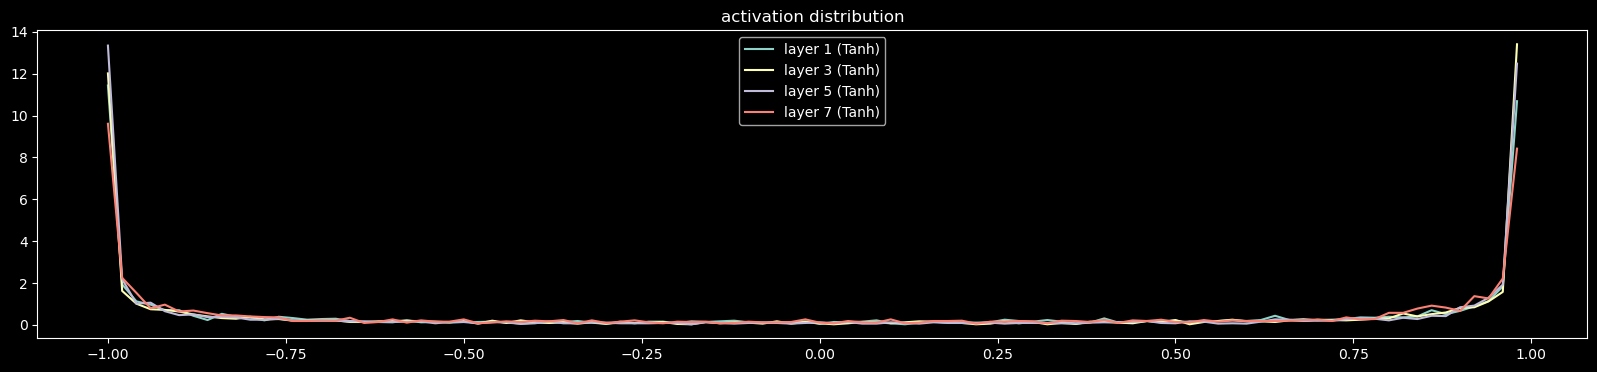

In [18]:
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print(f'layer {i}, {layer.__class__.__name__}: mean={t.mean().item():.2f}, std={t.std().item():.2f}, saturated={(t.abs() > 0.97).float().mean().item() * 100:.2f}%')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach().tolist(), hy.detach().tolist())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')


### 激活分布图如何读取

横轴是 `tanh` 输出值，纵轴是密度；每条曲线对应一个隐藏层的 `Tanh`。如果曲线大量堆在 $-1$ 和 $1$ 附近，说明激活饱和，局部导数 $1-\tanh^2(x)$ 偏小；如果主要集中在中间区域，通常更利于梯度传播。


layer 1 Tanh: mean=+0.000029, std=6.458e-03
layer 3 Tanh: mean=-0.000074, std=5.093e-03
layer 5 Tanh: mean=+0.000040, std=4.852e-03
layer 7 Tanh: mean=+0.000013, std=4.935e-03


Text(0.5, 1.0, 'gradient distribution')

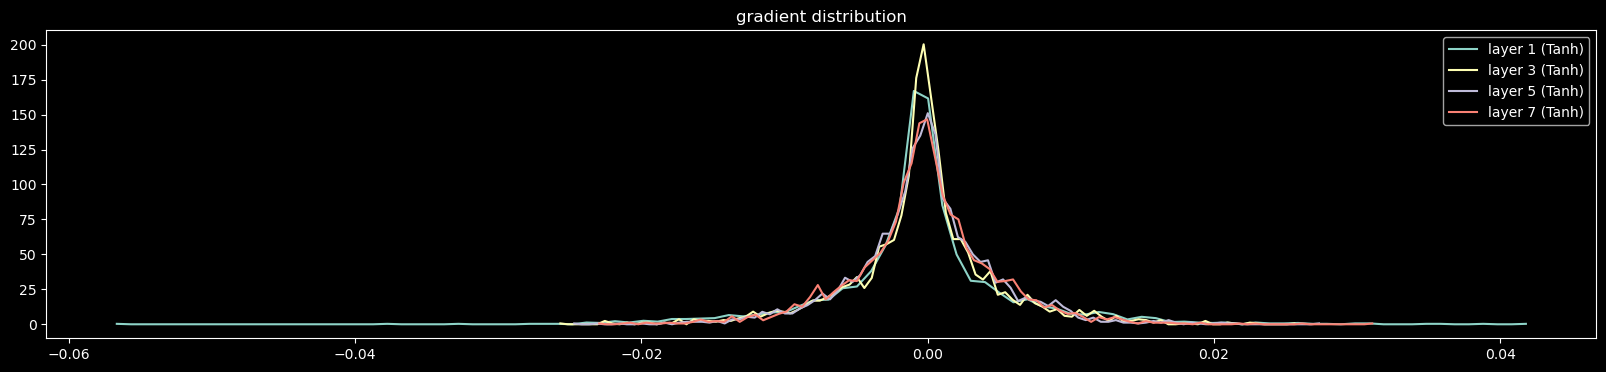

In [19]:

# visualize histograms
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh) and layer.out.grad is not None:
        t = layer.out.grad
        print(f'layer {i} {layer.__class__.__name__}: mean={t.mean().item():+.6f}, std={t.std().item():.3e}')
        hy, hx = torch.histogram(t, density=True)
        label = f'layer {i} ({layer.__class__.__name__})'
        plt.plot(hx[:-1].detach().tolist(), hy.detach().tolist(), label=label)
        legends.append(label)
plt.legend(legends)
plt.title('gradient distribution')


### 中间层梯度图如何读取

横轴是中间层输出的梯度值，纵轴是密度；每条曲线对应一个 `Tanh` 层的 `out.grad`。曲线越集中在 0 附近，说明该层本次 batch 的梯度越小；需要结合标准差和参数更新量判断是稳定的小梯度，还是梯度消失。


## 线性层与 `tanh` 的对比

同一组输入、权重和两层线性变换分别经过 `tanh` 与不经过 `tanh`。不含激活函数时，多个线性层仍可合并为一个线性变换；加入 `tanh` 后，模型才获得非线性表达能力。

下面的代码只做这个局部对比，不参与前面的训练参数和采样结果。


In [20]:
torch.manual_seed(42)
x_demo = torch.randn(8, 3)
w_demo_1 = torch.randn(3, 4)
w_demo_2 = torch.randn(4, 2)
linear_only = (x_demo @ w_demo_1) @ w_demo_2
with_tanh = torch.tanh(x_demo @ w_demo_1) @ w_demo_2
merged_weight = w_demo_1 @ w_demo_2
print('linear layers can merge:', torch.allclose(linear_only, x_demo @ merged_weight))
print('tanh changes result:', not torch.allclose(linear_only, with_tanh))


linear layers can merge: True
tanh changes result: True


# 如果没有tanh
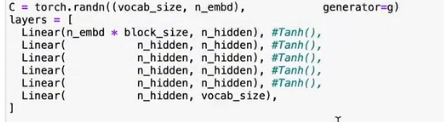

> 图 16：构造没有 `tanh` 的深层网络：把上面的层结构里所有 `Tanh()` 注释掉（`#Tanh()`），得到纯 Linear 的堆叠。
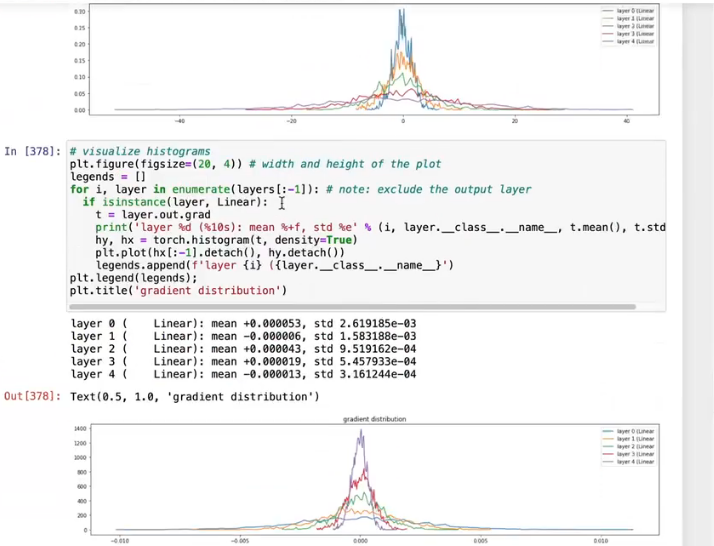

> 图 17：无 `tanh` 模型的梯度分布（代码 + 直方图）：梯度集中在 0 附近、尺度很小，与上面带 `tanh` 模型的激活/梯度分布对照，观察非线性对梯度传播的影响。
图 16 是无 `tanh` 的层结构，图 17 是它的梯度分布。没有激活函数时，连续线性层可以合并为一个线性变换（上面的单步验证也说明了这一点）；加入 `tanh` 后，输出不再满足这种合并关系，因此可以表达非线性关系。


weight (27, 10) | mean -0.001776 | std +3.129217e-02
weight (30, 100) | mean -0.000018 | std +1.712662e-02
weight (100,) | mean +0.000258 | std +1.419224e-02
weight (100, 100) | mean +0.000029 | std +9.591134e-03
weight (100,) | mean +0.000253 | std +8.703591e-03
weight (100, 100) | mean -0.000046 | std +8.490652e-03
weight (100,) | mean -0.000427 | std +9.796958e-03
weight (100, 100) | mean -0.000088 | std +8.392541e-03
weight (100,) | mean +0.000089 | std +8.046872e-03
weight (100, 27) | mean +0.000000 | std +2.271108e-02
weight (27,) | mean +0.000000 | std +2.447357e-02


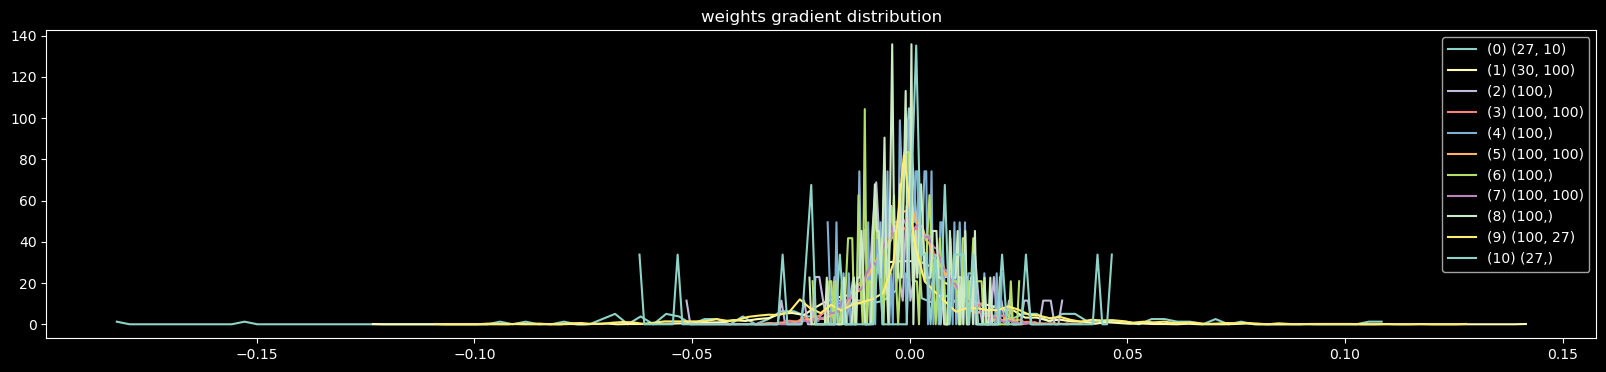

In [21]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
    if p.grad is not None:
        t = p.grad
        print(f'weight {tuple(p.shape)} | mean {t.mean().item():+f} | std {t.std().item():+e}')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach().tolist(), hy.detach().tolist())
        legends.append(f'({i}) {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');


### 参数梯度图如何读取

每条曲线对应一个参数张量的梯度分布。代码同时打印均值与标准差：均值接近 0 并不代表没有学习，关键还要看标准差是否非零，以及下一张更新比例图。没有参与当前前向的参数会被跳过。


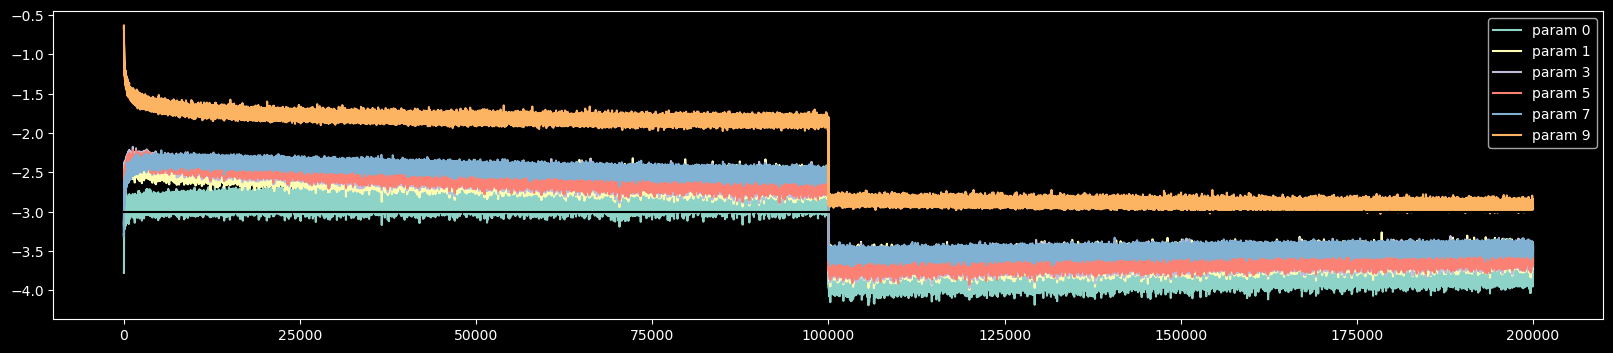

In [22]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)

plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

### 参数更新比例图如何读取

纵轴记录 `log10(lr * grad.std() / data.std())`。黑色参考线 `-3` 表示更新量约为参数尺度的千分之一；曲线远高于它可能意味着步长过大，长期低于它则可能意味着学习过慢。当前代码的 `ud` 由多步训练记录，因此该图不再只是单步快照。

100000 步处所有曲线整体下掉恰好 1 个单位，是学习率 `0.1 → 0.01` 造成的：纵轴公式里乘了 `lr`，`log10` 坐标下 10 倍的 lr 下降正好对应 -1。断层之后曲线走平，说明梯度本身没有突变，训练连续，只是步子变小了。


### 参数更新比例图

横轴是训练步，纵轴是 `log10(lr * grad.std() / data.std())`。黑色参考线 `-3` 表示更新量约为参数尺度的千分之一；曲线用于观察不同参数组的更新速度是否过大或过小。


下一步：放入BatchNorm1d
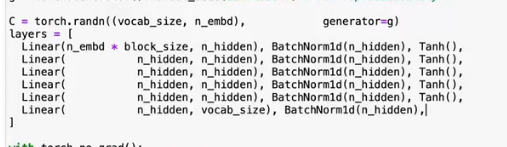

> 图 18：下一阶段 `BatchNorm1d` 模块化结构示意，目标是把线性层、批归一化、激活函数和训练诊断串成可复用组件。
三个目标：
1. 学会批归一化
2. 把部分代码Pytorch化
3. 部分诊断工具判断训练的效果

### 图片说明

该示意图把下一阶段的三个目标放在一起：理解 `BatchNorm1d` 的训练/推理语义，将线性、归一化和激活步骤封装为模块，并用激活、梯度和更新比例图判断训练状态。


## BatchNorm 全面上线：bias 退场、饱和率减半

上面诊断图里的 U 形饱和是"只有初始化、没有 BN"的形态。这节把 BatchNorm 真正铺进网络，四个改动一次到位：

1. **每个 `Linear` 都 `bias=False`**——反正后面跟的 BN 会减均值，bias 是无效参数；
2. **每层 Linear 后面都跟一个 `BatchNorm1d`**（输出层后面也跟）；
3. **增益归一**：`5/3` 的 tanh 增益不再需要（BN 每层重新校准），只有输出层的 `gamma *= 0.1` 用来压低初始置信度；
4. **学习率衰减挪到 150k**（前面的诊断图保持在 100k，两版不混）。

下面按这个完整配方重建网络并训练，看看三个问题有没有答案：开局 loss 能否贴住理论值、饱和率降多少、train/val 能不能刷新最佳。

In [ ]:
# 官方 Part 3 最终版配方：Linear(bias=False) + BatchNorm1d 每层跟随
n_emb_off = 10   # the dimensionality of the character embedding vectors
n_hidden_off = 100  # the number of neurons in the hidden layer of the MLP
g_off = torch.Generator().manual_seed(2147483647)  # for reproducibility
C_off = torch.randn((vocab_size, n_emb_off), generator=g_off)
layers_off = [
    Linear(n_emb_off * block_size, n_hidden_off, bias=False), BatchNorm1d(n_hidden_off), Tanh(),
    Linear(n_hidden_off, n_hidden_off, bias=False), BatchNorm1d(n_hidden_off), Tanh(),
    Linear(n_hidden_off, n_hidden_off, bias=False), BatchNorm1d(n_hidden_off), Tanh(),
    Linear(n_hidden_off, n_hidden_off, bias=False), BatchNorm1d(n_hidden_off), Tanh(),
    Linear(n_hidden_off, n_hidden_off, bias=False), BatchNorm1d(n_hidden_off), Tanh(),
    Linear(n_hidden_off, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
with torch.no_grad():
    # last layer: make less confident
    layers_off[-1].gamma *= 0.1
    # all other layers: apply gain (BN 已接管校准，这里保持 1.0)
    for layer in layers_off[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0
parameters_off = [C_off] + [p for layer in layers_off for p in layer.parameters()]
print(sum(p.nelement() for p in parameters_off))
for p in parameters_off:
    p.requires_grad = True

In [ ]:
# same optimization as last time（官方版：lr 衰减在 150k）
max_steps_off = 200000
batch_size_off = 32
lossi_off = []
ud_off = []

for i in range(max_steps_off):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size_off,), generator=g_off)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C_off[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers_off:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for layer in layers_off:
        layer.out.retain_grad()  # AFTER_DEBUG: would take out retain_graph
    for p in parameters_off:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters_off:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps_off:7d}: {loss.item():.4f}')
    lossi_off.append(loss.log10().item())
    with torch.no_grad():
        ud_off.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters_off])

In [ ]:
# 官方版诊断：激活 / 中间梯度 / 更新比例
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers_off[:-1]):  # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print(f'layer {i}, {layer.__class__.__name__}: mean={t.mean().item():.2f}, std={t.std().item():.2f}, saturated={(t.abs() > 0.97).float().mean().item() * 100:.2f}%')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach().tolist(), hy.detach().tolist())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution (official-style, with BN)')

In [ ]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss_off(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C_off[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers_off:
        layer.training = False  # 推理态：BN 使用 running 统计
    for layer in layers_off:
        x = layer(x)
    for layer in layers_off:
        layer.training = True   # 恢复训练态标志
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

split_loss_off('train')
split_loss_off('val')

### 本章 loss 演进小结

从原版 MLP 到完整 BN 版的完整路径（同种子，数字可复现）：

| 阶段 | 做法 | train / val |
| --- | --- | --- |
| 单隐层原版 | 标准正态初始化 | 2.1256 / 2.1674 |
| 压低初始置信 | `W2 *= 0.01` + `b2 *= 0` | 2.07 / 2.13 |
| 缓解 tanh 饱和 | `W1` 缩放、`b1 *= 0.01` | 2.035597 / 2.102679 |
| 方差守恒初始化 | Kaiming 缩放 `5/3 / sqrt(fan_in)` | 2.037665 / 2.106989 |
| BN 全面上线 | `bias=False` + 每层 BN + 输出层 `gamma *= 0.1` | **2.001990 / 2.082833** |

三个训练结论：

1. **开局 loss = 3.3001**，紧贴理论值 $\ln 27 = 3.2958$——"先学谦虚"的几万步从第 0 步就省掉。
2. **train 2.0020 / val 2.0828，全场最佳**：第一个把 val 压到 2.1 以下的配置。
3. **饱和率从 42%–56% 降到 18.7%–24.3%**，激活 std 从 0.85–0.90 收回 0.73–0.79：激活离开两极，梯度通路改善。

注意学习率衰减位置：前面的更新比例图在 100k（沿用 cell 23），本节用 150k，所以更新比例断层不在同一位置——看图时别混了两个训练的坐标。